In [1]:
# %pip install tensorflow opencv-python streamlit pandas scikit-learn Pillow


In [1]:
import os
import cv2
import glob

In [2]:

def preprocess_images(input_dir, output_dir, img_size=(224, 224)):

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    image_paths = []
    for ext in ('*.png', '*.jpg', '*.jpeg', '*.bmp'):
        image_paths.extend(glob.glob(os.path.join(input_dir, ext)))

    for img_path in image_paths:
        filename = os.path.basename(img_path)
        img = cv2.imread(img_path)

        if img is None:
            print(f"Failed to read {img_path}")
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)

        resized = cv2.resize(thresh, img_size)

        out_path = os.path.join(output_dir, filename)
        cv2.imwrite(out_path, resized)

    print(f"Processed {len(image_paths)} images from {input_dir} to {output_dir}")

def main():
    base_dir = os.getcwd()
    raw_forg_dir = os.path.join(base_dir, 'signatures', 'full_forg')
    raw_org_dir = os.path.join(base_dir, 'signatures', 'full_org')

    proc_forg_dir = os.path.join(base_dir, 'processed_data', 'full_forg')
    proc_org_dir = os.path.join(base_dir, 'processed_data', 'full_org')

    print("Starting image preprocessing...")
    preprocess_images(raw_org_dir, proc_org_dir)
    preprocess_images(raw_forg_dir, proc_forg_dir)
    print("Preprocessing completed!")

if __name__ == "__main__":
    main()

Starting image preprocessing...
Processed 1320 images from /Users/nih5586/PyCharmMiscProject/ML_A8/signatures/full_org to /Users/nih5586/PyCharmMiscProject/ML_A8/processed_data/full_org
Processed 1320 images from /Users/nih5586/PyCharmMiscProject/ML_A8/signatures/full_forg to /Users/nih5586/PyCharmMiscProject/ML_A8/processed_data/full_forg
Preprocessing completed!


In [3]:
import os
import glob
import pandas as pd

def create_dataset():
    NAMES = [
        "Aarav", "Vivaan", "Aditya", "Vihaan", "Arjun", "Sai", "Ayaan", "Krishna", "Ishaan", "Shaurya",
        "Atharv", "Advik", "Pranav", "Reyansh", "Moksh", "Dhruv", "Kabir", "Ritvik", "Aarush", "Kian",
        "Darsh", "Veer", "Ansh", "Laksh", "Dev", "Ishan", "Yash", "Samar", "Karaan", "Rudra",
        "Ananya", "Diya", "Saanvi", "Aditi", "Ira", "Kavya", "Ahana", "Riya", "Myra", "Navya",
        "Sara", "Meera", "Aarohi", "Priya", "Neha", "Pooja", "Anjali", "Shruti", "Swati", "Nidhi",
        "Roshni", "Simran", "Tanvi", "Vidya", "Kriti"
    ]
    id_to_name = {i: name for i, name in enumerate(NAMES, start=1)}

    base_dir = os.getcwd()
    proc_forg_dir = os.path.join(base_dir, 'processed_data', 'full_forg')
    proc_org_dir = os.path.join(base_dir, 'processed_data', 'full_org')

    data = []

    org_images = glob.glob(os.path.join(proc_org_dir, '*.*'))
    for img_path in org_images:
        filename = os.path.basename(img_path)
        name_without_ext = os.path.splitext(filename)[0]
        parts = name_without_ext.split('_')
        if len(parts) >= 2:
            student_id = int(parts[1])
            student_name = id_to_name.get(student_id, "Unknown")
            data.append({
                'File_Path': img_path,
                'ID': student_id,
                'Student_Name': student_name,
                'Label': 0
            })

    forg_images = glob.glob(os.path.join(proc_forg_dir, '*.*'))
    for img_path in forg_images:
        filename = os.path.basename(img_path)
        name_without_ext = os.path.splitext(filename)[0]
        parts = name_without_ext.split('_')
        if len(parts) >= 2:
            student_id = int(parts[1])
            student_name = id_to_name.get(student_id, "Unknown")
            data.append({
                'File_Path': img_path,
                'ID': student_id,
                'Student_Name': student_name,
                'Label': 1
            })

    df = pd.DataFrame(data)
    csv_path = os.path.join(base_dir, 'dataset.csv')
    df.to_csv(csv_path, index=False)
    print(f"Created dataset with {len(df)} records. Saved to {csv_path}")

if __name__ == "__main__":
    create_dataset()

Created dataset with 2640 records. Saved to /Users/nih5586/PyCharmMiscProject/ML_A8/dataset.csv


In [15]:
import os
import pandas as pd
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split

def load_data(csv_path):
    df = pd.read_csv(csv_path)
    X = []
    y_id = []
    y_verify = []

    for index, row in df.iterrows():
        img_path = row['File_Path']
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (224, 224))
        img = img / 255.0
        X.append(img)
        y_id.append(row['ID'] - 1)
        y_verify.append(row['Label'])

    X = np.array(X).reshape(-1, 224, 224, 1)
    y_id = np.array(y_id)
    y_verify = np.array(y_verify)
    return X, y_id, y_verify

def build_id_model(input_shape=(224, 224, 1), num_classes=55):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_verify_model(input_shape=(224, 224, 1)):
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

def main():
    base_dir = os.getcwd()
    csv_path = os.path.join(base_dir, 'dataset.csv')

    if not os.path.exists(csv_path):
        print("dataset.csv not found. Please run create_dataset.py first.")
        return

    print("Loading data...")
    X, y_id, y_verify = load_data(csv_path)

    print("Training ID Model...")
    X_train, X_test, y_train, y_test = train_test_split(X, y_id, test_size=0.2, random_state=42)
    id_model = build_id_model()
    id_model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), batch_size=32)
    id_model.save('student_id_model.h5')
    print("Saved student_id_model.h5")

    print("Training Verify Model...")
    X_train, X_test, y_train, y_test = train_test_split(X, y_verify, test_size=0.2, random_state=42)
    verify_model = build_verify_model()
    verify_model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test), batch_size=32)
    verify_model.save('forgery_detect_model.h5')
    print("Saved forgery_detect_model.h5")

if __name__ == "__main__":
    main()


Loading data...
Training ID Model...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 483ms/step - accuracy: 0.1117 - loss: 3.6965 - val_accuracy: 0.4848 - val_loss: 2.3862
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 498ms/step - accuracy: 0.4280 - loss: 2.1917 - val_accuracy: 0.6496 - val_loss: 1.5260
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 495ms/step - accuracy: 0.6184 - loss: 1.3848 - val_accuracy: 0.7500 - val_loss: 1.0070
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 33s 496ms/step - accuracy: 0.7500 - loss: 0.8853 - val_accuracy: 0.8049 - val_loss: 0.7761
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 36s 545ms/step - accuracy: 0.8433 - loss: 0.5271 - val_accuracy: 0.8409 - val_loss: 0.6874


Saved student_id_model.h5
Training Verify Model...
Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 552ms/step - accuracy: 0.6259 - loss: 0.7472 - val_accuracy: 0.6932 - val_loss: 0.5694
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 586ms/step - accuracy: 0.7339 - loss: 0.5315 - val_accuracy: 0.7330 - val_loss: 0.5336
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 39s 588ms/step - accuracy: 0.7978 - loss: 0.4466 - val_accuracy: 0.7841 - val_loss: 0.4678
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 38s 583ms/step - accuracy: 0.8305 - loss: 0.3778 - val_accuracy: 0.7746 - val_loss: 0.4642
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 37s 556ms/step - accuracy: 0.8778 - loss: 0.2971 - val_accuracy: 0.7841 - val_loss: 0.4627


Saved forgery_detect_model.h5


In [5]:
import tensorflow as tf

id_model = tf.keras.models.load_model("student_id_model.h5")
verify_model = tf.keras.models.load_model("forgery_detect_model.h5")

print("Models loaded successfully")

Models loaded successfully


In [8]:
import cv2
import numpy as np

def predict_signature(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (224,224))
    img = img / 255.0
    img = img.reshape(1,224,224,1)

    id_pred = id_model.predict(img)
    student_id = np.argmax(id_pred) + 1

    verify_pred = verify_model.predict(img)
    result = "Genuine" if verify_pred[0][0] > 0.5 else "Forged"

    print("Predicted Student ID:", student_id)
    print("Signature Type:", result)

In [9]:
predict_signature("processed_data/full_org/original_1_1.png")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Predicted Student ID: 1
Signature Type: Forged


In [10]:
import matplotlib.pyplot as plt

def show_prediction(image_path):

    img = cv2.imread(image_path,0)
    img_resized = cv2.resize(img,(224,224))
    img_norm = img_resized/255.0
    img_input = img_norm.reshape(1,224,224,1)

    id_pred = id_model.predict(img_input)
    student_id = np.argmax(id_pred)+1

    verify_pred = verify_model.predict(img_input)
    result = "Genuine" if verify_pred[0][0] > 0.5 else "Forged"

    plt.imshow(img, cmap="gray")
    plt.title(f"Student ID: {student_id} | {result}")
    plt.axis("off")
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


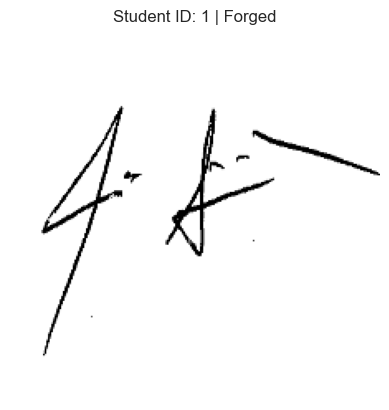

In [11]:
show_prediction("processed_data/full_org/original_1_1.png")

In [12]:
#!pip install ipywidgets

In [13]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import cv2

upload = widgets.FileUpload(
    accept='.png,.jpg,.jpeg,.bmp',
    multiple=False
)

display(upload)

FileUpload(value=(), accept='.png,.jpg,.jpeg,.bmp', description='Upload')

In [14]:
    for file in upload.value:

        content = file['content']
        nparr = np.frombuffer(content, np.uint8)
        img = cv2.imdecode(nparr, cv2.IMREAD_GRAYSCALE)

        img_resized = cv2.resize(img,(224,224))
        img_norm = img_resized / 255.0
        img_input = img_norm.reshape(1,224,224,1)

        id_pred = id_model.predict(img_input)
        student_id = np.argmax(id_pred) + 1

        verify_pred = verify_model.predict(img_input)
        result = "Forged" if verify_pred[0][0] > 0.5 else "Genuine"

        print("Predicted Student ID:", student_id)
        print("Signature Type:", result)

